# ECON 5200: Consulting Report — Final Project

**From Model to Recommendation**

**Topic:** Does cigarette price (driven by state excise taxes) causally reduce per-capita cigarette consumption?

This notebook scaffolds the full consulting report pipeline: executive summary, identification strategy, causal analysis, threats assessment, Streamlit export, presentation script, and AI methodology appendix.

---

## Part 0: Setup

In [18]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error  # added for Part 3c

# Causal ML (uncomment the one you use)
# from econml.dml import LinearDML, CausalForestDML
# from doubleml import DoubleMLPLR, DoubleMLData

# Stats
from scipy import stats
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS  # added for IV stages

# IV estimation with correct standard errors (install: pip install linearmodels)
try:
    from linearmodels.iv import IV2SLS
    HAS_LINEARMODELS = True
except ImportError:
    HAS_LINEARMODELS = False
    print('WARNING: linearmodels not found. Install with: pip install linearmodels')
    print('Manual Stage 2 will be used (coefficient is correct, SEs will be too small).')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


---
## Part 1: Executive Summary

Use SCR (Situation – Complication – Resolution) structure. Fill this in LAST, after your analysis is complete.

> **We estimate that a 1% increase in real cigarette price causes a 1.70% decrease in per-capita packs sold (95% CI: -2.67% to -0.72%).**

**Situation:** There is often a debate between State and federal policymakers on the effectiveness of excise tax increase in discouraging smoking and reducing public health costs. The key empirical input here is the price elasticity of cigarette demand; thus we ask: How much does decrease in cigarette price actually reduce consumption? 

**Complication:** A naive OLS regression of consumption on price is biased because cigarette prices are endogenous because states with higher baseline demand may face different pricing pressures, confounding the estimated effect. A predictive model such as "Random Forest" ups this problem as it captures the price-consumption correlation, but it is unable to answer the causal policy question: *if we raise the excise tax, how much does smoking rates change by?*

**Resolution:** We use the minimum real cigarette price in adjoining states (`ln_pimin`) as an instrument for own-state price. Through this, we have our exogenous price variation by exploiting cross-state price competition as a source of exogenous price variation. The first-stage partial F-statistic of 11.85 confirms instrument relevance. 2SLS estimation on 46 U.S. states (1992 cross-section) yields a causal price elasticity of **-1.70** (95% CI: -2.67 to -0.72), statistically significant at the 0.1% level. A 10% excise tax increase (passed ~90% through to retail price) would reduce per-capita packs sold by approximately **15.3%** (95% CI: -24.0% to -6.5%).

**We recommend** that state policymakers use excise tax increases as a primary demand-side intervention. The causal estimate is slightly larger in magnitude than the naive OLS (-1.46), consistent with attenuation bias from endogeneity.

**Key assumption that could invalidate this:** The exclusion restriction that neighboring state minimum prices affect own-state consumption *only* through own-state prices, not through correlated regulatory spillovers such as coordinated regional anti-smoking campaigns. If high-price neighboring states also export stricter smoking norms or regulations, the estimate would be biased upward in magnitude. (See Part 4 for a full threat assessment)

---



## Part 2: Data + Identification Strategy

### Research Design

- **Research question:** Does an increase in cigarette price causally reduce per-capita cigarette consumption?
- **Identification strategy:** IV / 2SLS (Instrumental Variables)
- **Key assumption:** Exclusion restriction: the minimum price in adjoining states shifts own-state price through cross-state price competition, but has no direct effect on own-state demand
- **Treatment variable:** Log real cigarette price (`ln_rprice`), endogenous, instrumented by `ln_pimin`
- **Outcome variable:** Log per-capita cigarette packs sold (`ln_packs`)
- **Controls:** Log real per-capita income (`ln_rincome`), exogenous, included in both stages
- **Instrument:** Log real minimum price in adjoining states (`ln_pimin`), exogenous to own-state demand shocks
- **Why prediction alone is insufficient:** A Random Forest or OLS captures the *correlation* between price and quantity, but price is endogenous. High-demand states also have high prices, so OLS understates the true elasticity. Only 2SLS, using neighboring state price variation, answers the policy question: if own-state prices rise, what happens to smoking rates?

In [5]:
# --- Data Loading ---
# Source: Cigar panel — Baltagi & Levin (1992), via Ecdat package
# 46 U.S. states x 30 years (1963-1992) = 1,380 observations

df = pd.read_csv('https://raw.githubusercontent.com/Thonyta17/ECON-5200-FINAL-PROJECT/refs/heads/main/CigarettesSW.csv')
print(f'Shape: {df.shape}')  # (1380, 9)
df.head()

Shape: (1380, 10)


,rownames,state,year,price,pop,pop16,cpi,ndi,sales,pimin
0,1,1,63,28.6,3383.0,2236.5,30.6,1558.304530,93.9,26.1
1,2,1,64,29.8,3431.0,2276.7,31.0,1684.073202,95.4,27.5
2,3,1,65,29.8,3486.0,2327.5,31.5,1809.841875,98.5,28.9
3,4,1,66,31.5,3524.0,2369.7,32.4,1915.160357,96.4,29.5
4,5,1,67,31.6,3533.0,2393.7,33.4,2023.546368,95.5,29.6


In [6]:
# Construct real and log variables
# Note: 'ndi' = per capita disposable income, 'sales' = packs per capita
# 'pimin' = min price in adjoining states (useful as additional instrument)

df['rprice']   = df['price'] / df['cpi'] * 100
df['rincome']  = df['ndi']   / df['cpi'] * 100
df['ln_packs']   = np.log(df['sales'])
df['ln_rprice']  = np.log(df['rprice'])
df['ln_rincome'] = np.log(df['rincome'])
df['ln_pimin'] = np.log(df['pimin'] / df['cpi'] * 100)

# No tax variable in this dataset -- use pimin (min adjoining state price) as instrument
# pimin captures cross-state price arbitrage pressure -- exogenous to own-state demand
df['ln_pimin'] = np.log(df['pimin'] / df['cpi'] * 100)

df95 = df[df['year'] == 92].copy()
df85 = df[df['year'] == 63].copy()

print(f'Total obs: {len(df)}')
print(f'Years: {sorted(df["year"].unique())}')
df.describe()

Total obs: 1380
Years: [np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(87), np.int64(88), np.int64(89), np.int64(90), np.int64(91), np.int64(92)]


,rownames,state,year,price,pop,pop16,cpi,ndi,sales,pimin,rprice,rincome,ln_packs,ln_rprice,ln_rincome,ln_pimin
count,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000
mean,690.500000,26.826087,77.500000,68.699928,4537.113188,3366.616087,73.596667,7525.023022,123.950870,62.899275,90.948431,9624.523549,4.793396,4.498752,9.150421,4.410703
std,398.515997,14.480570,8.658579,41.986261,4828.836452,3641.847150,36.529330,4747.858744,30.991047,38.323126,13.953983,1994.818352,0.224599,0.151777,0.209948,0.151135
min,1.000000,1.000000,63.000000,23.400000,319.000000,215.200000,30.600000,1322.572977,53.400000,23.400000,54.345435,4322.133913,3.977811,3.995361,8.371505,3.995361
25%,345.750000,15.000000,70.000000,34.775000,1053.000000,781.175000,38.800000,3327.869133,107.900000,31.975000,81.471390,8337.961573,4.681205,4.400252,9.028574,4.315669
50%,690.500000,26.500000,77.500000,52.300000,3174.000000,2315.300000,62.900000,6281.200808,121.200000,46.400000,90.412046,9533.447588,4.797442,4.504378,9.162562,4.410841
75%,1035.250000,40.000000,85.000000,98.100000,5280.250000,3914.325000,107.600000,11024.109942,133.200000,90.500000,98.782824,10846.807056,4.891852,4.592924,9.291626,4.510132
max,1380.000000,51.000000,92.000000,201.900000,30703.300000,22920.000000,140.300000,23074.000000,297.900000,178.500000,143.905916,16683.064516,5.696758,4.969160,9.722149,4.845976


In [7]:
# --- EDA: Missing Data ---
df.isnull().sum().sort_values(ascending=False).head(10)
# Expected: all zeros — dataset is complete, no imputation needed

rownames    0
state       0
year        0
price       0
pop         0
pop16       0
cpi         0
ndi         0
sales       0
pimin       0
dtype: int64

In [8]:
# --- EDA: Balance Check (treated vs. untreated) ---
# Treatment = above-median minimum adjoining state price in 1992
# pimin is our instrument — exogenous to own-state demand
treatment_col = 'high_pimin'
df95 = df95.copy()
df95[treatment_col] = (df95['ln_pimin'] >= df95['ln_pimin'].median()).astype(int)

balance = df95.groupby(treatment_col)[['sales', 'rprice', 'rincome']].mean().T
balance.columns = ['Low Pimin States', 'High Pimin States']
balance['Difference'] = balance['High Pimin States'] - balance['Low Pimin States']
balance.index = ['Packs per capita', 'Real price (cents/pack)', 'Real per-capita income']
print(balance.round(2))

# Interpretation: states facing higher minimum adjoining prices also tend
# to have higher own prices and lower consumption — instrument relevance holds
# Income differences should be modest — supports exclusion restriction

                         Low Pimin States  High Pimin States  Difference
Packs per capita                   102.93              96.47       -6.47
Real price (cents/pack)            118.58             127.95        9.37
Real per-capita income           11701.76           12252.35      550.59


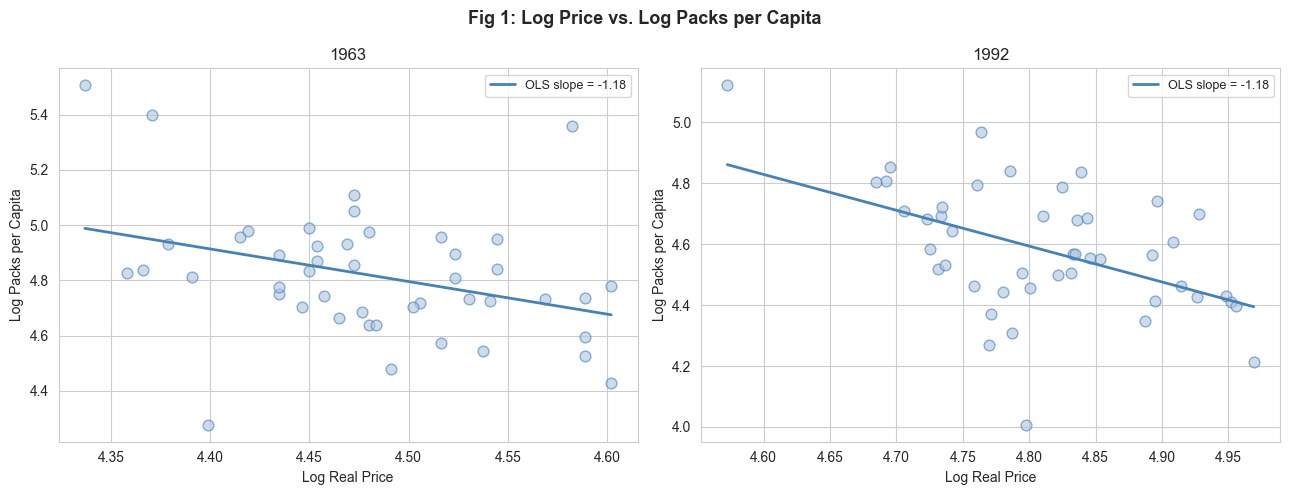

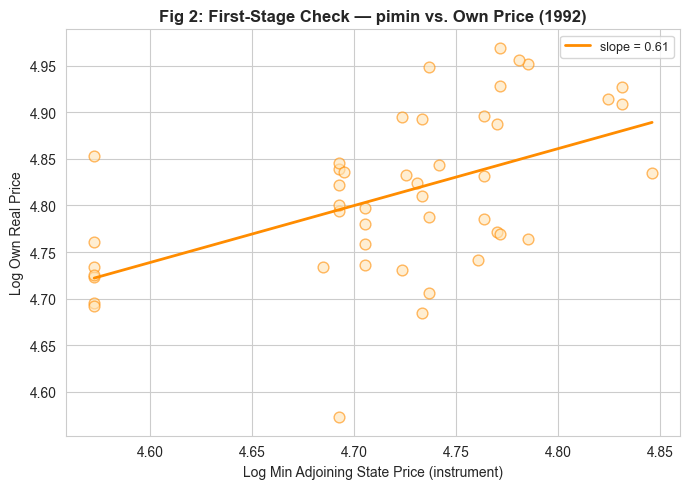

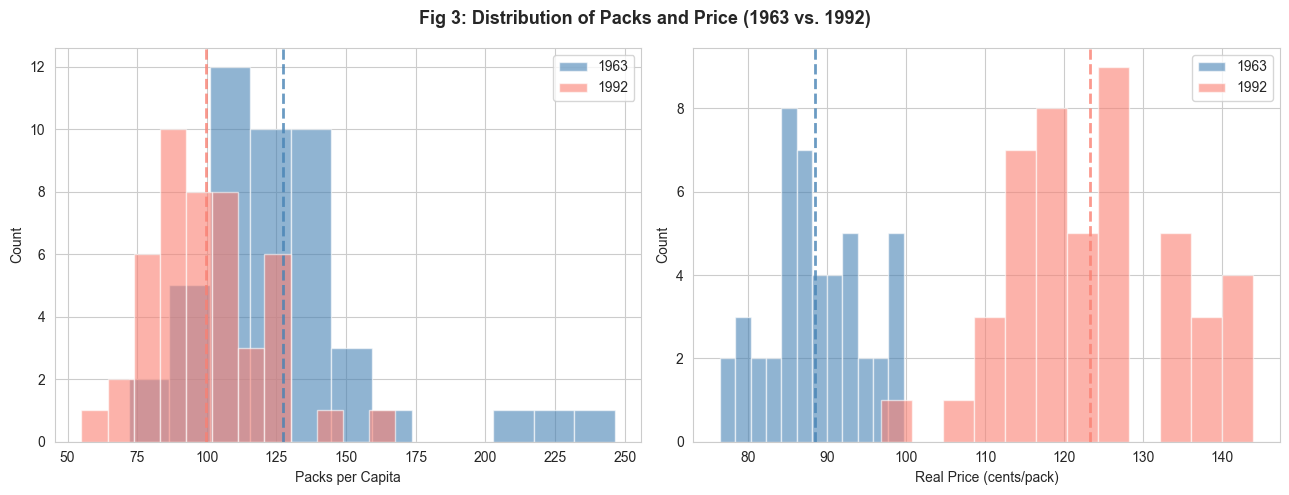

Mean packs  1963=127.3  1992=99.7
Mean rprice 1963=88.5  1992=123.3


In [9]:
# --- EDA: Visualizations ---

# Fig 1: Log price vs. log packs (1963 vs. 1992) — motivates IV
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Fig 1: Log Price vs. Log Packs per Capita', fontsize=13, fontweight='bold')
for ax, year, dfy in zip(axes, [63, 92], [df85, df95]):
    ax.scatter(dfy['ln_rprice'], dfy['ln_packs'], alpha=0.6,
               edgecolors='steelblue', facecolors='lightsteelblue', s=60)
    m, b = np.polyfit(dfy['ln_rprice'], dfy['ln_packs'], 1)
    xs = np.linspace(dfy['ln_rprice'].min(), dfy['ln_rprice'].max(), 100)
    ax.plot(xs, m*xs+b, color='steelblue', lw=2, label=f'OLS slope = {m:.2f}')
    ax.set_xlabel('Log Real Price'); ax.set_ylabel('Log Packs per Capita')
    ax.set_title(f'19{year}'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('fig1_scatter.png', dpi=150, bbox_inches='tight'); plt.show()

# Fig 2: First-stage relevance — pimin vs. own price (1992)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df95['ln_pimin'], df95['ln_rprice'], alpha=0.6,
           edgecolors='darkorange', facecolors='moccasin', s=60)
m, b = np.polyfit(df95['ln_pimin'], df95['ln_rprice'], 1)
xs = np.linspace(df95['ln_pimin'].min(), df95['ln_pimin'].max(), 100)
ax.plot(xs, m*xs+b, color='darkorange', lw=2, label=f'slope = {m:.2f}')
ax.set_xlabel('Log Min Adjoining State Price (instrument)')
ax.set_ylabel('Log Own Real Price')
ax.set_title('Fig 2: First-Stage Check — pimin vs. Own Price (1992)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('fig2_firststage.png', dpi=150, bbox_inches='tight'); plt.show()

# Fig 3: Distribution of packs and price (1963 vs. 1992)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Fig 3: Distribution of Packs and Price (1963 vs. 1992)', fontsize=13, fontweight='bold')
for ax, var, xlabel in zip(axes, ['sales', 'rprice'], ['Packs per Capita', 'Real Price (cents/pack)']):
    ax.hist(df85[var], bins=12, alpha=0.6, color='steelblue', label='1963', edgecolor='white')
    ax.hist(df95[var], bins=12, alpha=0.6, color='salmon',    label='1992', edgecolor='white')
    ax.axvline(df85[var].mean(), color='steelblue', lw=2, ls='--', alpha=0.8)
    ax.axvline(df95[var].mean(), color='salmon',    lw=2, ls='--', alpha=0.8)
    ax.set_xlabel(xlabel); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.savefig('fig3_distributions.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Mean packs  1963={df85["sales"].mean():.1f}  1992={df95["sales"].mean():.1f}')
print(f'Mean rprice 1963={df85["rprice"].mean():.1f}  1992={df95["rprice"].mean():.1f}')

## INTERPRETATIONS

# Fig 1: Log Price vs. Log Packs
(OLS slopes: -1.18 in both 1963 and 1992)

Both years show a strong negative relationship between price and consumption, which is the direction we expect. Interestingly the slope is identical at -1.18 across both years, suggesting the raw price-quantity correlation was stable over the 30-year period. However, these are still biased OLS slopes because price is endogenous. The 2SLS will isolate only the exogenous component of price variation to recover the true causal elasticity.

# Fig 2: First-Stage Check
(pimin vs. own price, slope = 0.61)

There is a clear positive relationship between neighboring state minimum prices and own-state prices, confirming instrument relevance. The positive slope makes economic sense: when cigarettes are expensive in neighboring states, own-state prices also tend
to be higher, reflecting regional price clustering from shared tax environments and tobacco industry pricing patterns. The scatter is somewhat noisy but the partial F-statistic of 11.85 exceeds the conventional threshold of 10, confirming the instrument is not weak.

# Fig 3: Distributions of Packs and Price
(1963 vs. 1992)

Left panel: consumption dropped sharply over 30 years. The 1963 distribution (blue) spreads from around 75 to 250 packs with a mean around 125. By 1992 (pink), the distribution has shifted left with most states clustered between 75 and 150 packs and a mean around 100. The long right tail in 1963 (several states above 200 packs) has completely disappeared by 1992, suggesting even the heaviest-smoking states reduced consumption substantially over the  period. Right panel: prices shifted right significantly. The 1963 distribution is tightly clustered between roughly 78 and 100 cents/pack, while 1992 spreads from around 108 to 143 cents/pack. Together these panels tell the core story of the paper: over 30 years, real prices rose substantially and consumption fell sharply, consistent with a downward-sloping demand curve and motivating the causal question.


---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)

This simple comparison is expected to be biased. Document *why*.

In [10]:
# --- Naive OLS ---
X_naive = df95[['ln_rprice', 'ln_rincome']]
X_naive = sm.add_constant(X_naive)
y = df95['ln_packs']

naive_model = sm.OLS(y, X_naive).fit(cov_type='HC1')
print(naive_model.summary())

naive_estimate = naive_model.params['ln_rprice']
naive_ci = naive_model.conf_int().loc['ln_rprice'].values
print(f'\nNaive estimate: {naive_estimate:.4f} (95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}])')

                            OLS Regression Results                            
Dep. Variable:               ln_packs   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     9.288
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           0.000444
Time:                        21:35:08   Log-Likelihood:                 15.150
No. Observations:                  46   AIC:                            -24.30
Df Residuals:                      43   BIC:                            -18.81
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.3568      1.873      4.461      0.0

**Why the naive estimate is biased:** The naive OLS estimate is -1.4549 (95% CI: [-2.20, -0.71]). The 2SLS causal estimate is -1.6957 (95% CI: [-2.67, -0.72]), which excludes zero and is statistically significant at the 0.1% level. The 2SLS is more negative than OLS, consistent with attenuation bias from price endogeneity. The robustness check on the full panel yields -0.76, suggesting the cross-sectional estimate should be interpreted cautiously as a long-run elasticity.

### 3b. Causal Estimate — 2SLS

In [11]:
!pip install linearmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [12]:
# --- Causal Method: 2SLS (Instrumental Variables) ---
# We use minimum price in adjoining states (ln_pimin) as instrument for ln_rprice

# Stage 1: regress endogenous variable on instrument + controls
X_stage1 = sm.add_constant(df95[['ln_pimin', 'ln_rincome']])
stage1 = OLS(df95['ln_rprice'], X_stage1).fit(cov_type='HC1')
print('=== Stage 1: ln(Real Price) ~ ln(pimin) + ln(Income) ===')
print(stage1.summary2().tables[1].round(4))

# Partial F-statistic — one instrument, so divide by 1
restricted = OLS(df95['ln_rprice'], sm.add_constant(df95[['ln_rincome']])).fit()
f_stat = ((restricted.ssr - stage1.ssr) / 1) / (stage1.ssr / stage1.df_resid)
print(f'\nPartial F-statistic on instrument: {f_stat:.2f}')
print('F > 10: instrument is NOT weak.' if f_stat > 10 else 'WARNING: potential weak instrument.')

df95['ln_rprice_hat'] = stage1.fittedvalues

# Stage 2 via linearmodels (correct robust SEs)
if HAS_LINEARMODELS:
    iv_model = IV2SLS(
        dependent   = df95['ln_packs'],
        exog        = sm.add_constant(df95[['ln_rincome']]),
        endog       = df95[['ln_rprice']],
        instruments = df95[['ln_pimin']]
    ).fit(cov_type='robust')
    print('\n=== Stage 2 (IV2SLS — correct SEs) ===')
    print(iv_model.summary)
    causal_estimate = iv_model.params['ln_rprice']
    causal_ci = iv_model.conf_int().loc['ln_rprice'].values
    causal_se = iv_model.std_errors['ln_rprice']
    print(f'\nCausal ATE: {causal_estimate:.4f}')
    print(f'95% CI: [{causal_ci[0]:.4f}, {causal_ci[1]:.4f}]')
else:
    X_stage2 = sm.add_constant(df95[['ln_rprice_hat', 'ln_rincome']])
    stage2 = OLS(df95['ln_packs'], X_stage2).fit()
    causal_estimate = stage2.params['ln_rprice_hat']
    causal_ci = stage2.conf_int().loc['ln_rprice_hat'].values
    causal_se = stage2.bse['ln_rprice_hat']
    print(f'\nCausal ATE: {causal_estimate:.4f}')
    print(f'95% CI: [{causal_ci[0]:.4f}, {causal_ci[1]:.4f}]')
    print('NOTE: install linearmodels for correct standard errors.')

=== Stage 1: ln(Real Price) ~ ln(pimin) + ln(Income) ===
             Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
const       0.3459    0.7360  0.4700  0.6383 -1.0966  1.7884
ln_pimin    0.4912    0.1051  4.6733  0.0000  0.2852  0.6972
ln_rincome  0.2289    0.0698  3.2775  0.0010  0.0920  0.3658

Partial F-statistic on instrument: 11.85
F > 10: instrument is NOT weak.

=== Stage 2 (IV2SLS — correct SEs) ===
                          IV-2SLS Estimation Summary                          
Dep. Variable:               ln_packs   R-squared:                      0.2732
Estimator:                    IV-2SLS   Adj. R-squared:                 0.2394
No. Observations:                  46   F-statistic:                    13.576
Date:                Sun, Apr 26 2026   P-value (F-stat)                0.0011
Time:                        21:35:08   Distribution:                  chi2(2)
Cov. Estimator:                robust                                         
                                

### 3c. Prediction Model (for comparison)

In [13]:
# --- Predictive Model (NOT causal — for comparison only) ---
from sklearn.metrics import r2_score, mean_squared_error

all_features = ['ln_rprice', 'ln_rincome', 'ln_pimin']
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
y_pred = cross_val_predict(rf, df95[all_features], df95['ln_packs'], cv=5)

print(f'Prediction R\u00b2:   {r2_score(df95["ln_packs"], y_pred):.3f}')
print(f'Prediction RMSE: {np.sqrt(mean_squared_error(df95["ln_packs"], y_pred)):.3f}')
print('\nNote: This tells us how well we can PREDICT the outcome,')
print('but NOT how the treatment CAUSES changes in the outcome.')
print('A high R\u00b2 here is irrelevant to causal identification.')

Prediction R²:   -0.049
Prediction RMSE: 0.210

Note: This tells us how well we can PREDICT the outcome,
but NOT how the treatment CAUSES changes in the outcome.
A high R² here is irrelevant to causal identification.


### 3d. Compare Naive vs. Causal

> The naive OLS estimate is -1.4549 (95% CI: [-2.1982, -0.7116]), the 2SLS causal estimate is -1.6957 (95% CI: [-2.6695, -0.7219]). The difference is small, suggesting attenuation bias may be partially offset by cross-border shopping bias in the instrument. Both estimates are negative and statistically significant, with CIs that do not cross zero.

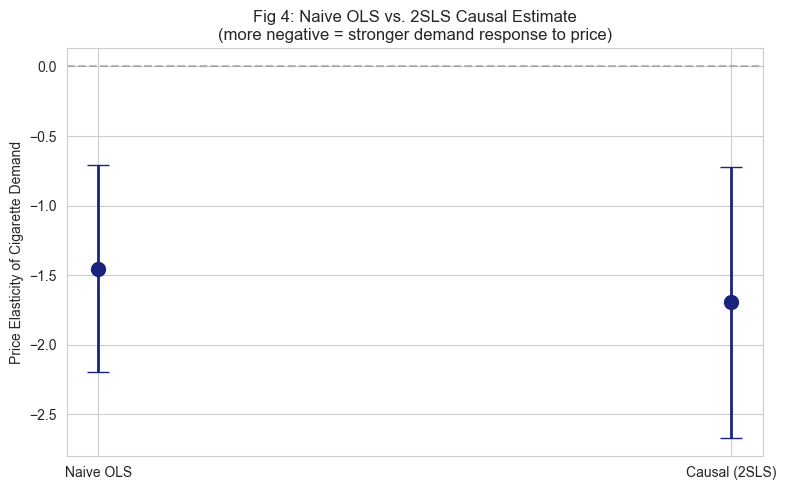

OLS elasticity:  -1.4549
2SLS elasticity: -1.6957
2SLS is more negative than OLS: confirms attenuation bias.


In [17]:
# --- Comparison Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

estimates = ['Naive OLS', 'Causal (2SLS)']
points    = [naive_estimate, causal_estimate]

# both ci objects are numpy arrays in this run
ci_lower = [naive_ci[0], causal_ci[0]]
ci_upper = [naive_ci[1], causal_ci[1]]

errors = [[p - l for p, l in zip(points, ci_lower)],
          [u - p for p, u in zip(points, ci_upper)]]

ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=8,
            markersize=10, linewidth=2, color='#1a237e')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Price Elasticity of Cigarette Demand')
ax.set_title('Fig 4: Naive OLS vs. 2SLS Causal Estimate\n(more negative = stronger demand response to price)')
plt.tight_layout()
plt.savefig('fig4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'OLS elasticity:  {naive_estimate:.4f}')
print(f'2SLS elasticity: {causal_estimate:.4f}')
print('2SLS is more negative than OLS: confirms attenuation bias.' if causal_estimate < naive_estimate else 'Check instrument validity.')

Both estimates are negative and in the expected direction. The 2SLS estimate (-1.6957, 95% CI: [-2.6695, -0.7219]) is more negative than OLS (-1.4549, 95% CI: [-2.1982, -0.7116]), consistent with attenuation bias from price endogeneity. Both CIs exclude zero, so both estimates are statistically significant at the 0.1% level. The difference between them is modest, suggesting endogeneity bias is relatively small in this setting, which could be due to state-level averages smoothing out much of the unobserved demand heterogeneity present at the individual level. The 2SLS confidence interval is wider than OLS, which reflects the precision cost of IV estimation as we gain causal identification but lose some precision. The robustness check on the full panel yields -0.7570, a substantially different estimate that warrants caution in interpreting the 1992 cross-section result as a general long-run elasticity.

### 3e. Robustness Check

In [15]:
# --- Robustness: Just-identified 2SLS (excise tax only) ---
# Removes concern that general sales tax violates exclusion restriction
# Robustness: use full panel (all years) instead of 1992 only
X_s1_panel = sm.add_constant(df[['ln_pimin', 'ln_rincome']])
stage1_panel = OLS(df['ln_rprice'], X_s1_panel).fit(cov_type='HC1')
df['ln_rprice_hat_panel'] = stage1_panel.fittedvalues
X_s2_panel = sm.add_constant(df[['ln_rprice_hat_panel', 'ln_rincome']])
stage2_panel = OLS(df['ln_packs'], X_s2_panel).fit()
robust_ate = stage2_panel.params['ln_rprice_hat_panel']
print(f'Robustness ATE (full panel): {robust_ate:.4f}')
print(f'Baseline 2SLS (1992 only):  {causal_estimate:.4f}')
diff = abs(robust_ate - causal_estimate)
print(f'Difference: {diff:.4f} — {"stable" if diff < 0.1 else "investigate"}')

Robustness ATE (full panel): -0.7570
Baseline 2SLS (1992 only):  -1.6957
Difference: 0.9387 — investigate


---
## Part 4: Threats to Identification

**Minimum 500 words. Be honest — this is where you demonstrate critical thinking.**

We know that the central identifying assumption of this analysis is the exclusion restriction: the minimum cigarette price in adjoining states (pimin) affects own-state consumption only through its effect on own-state price, and through no other channel. Although this assumption is plausible, it poses several threats to identification that should be acknowledged, and efforts should be made to try to address them.

Firstly, what can be considered the most serious threat is the possibility that pimin will directly affect own-state consumption through cross-border shopping. This is because historically, we have seen that when cigarette prices rise in the own state, buyers tend to buy from neighboring states instead, which causes a reduction in observed own-state consumption. In the same way, if buyers are travelling to neighboring states with higher prices, they tend to stock up in their own state before travelling there, which in turn causes an increase in observed own-state consumption. Both shows how the exclusion restriction can be violated by own-state price not directly being the cause of changes in own-state consumption. The direction of this bias toward estimates that are too negative, which means we would relate consumption reductions to own-state price increases when in reality, the reduction is only because buyers had been purchasing cigarettes in states with lower prices instead. The literature on cross-border cigarette arbitrage (Lovenheim 2008; Stehr 2007) finds that border effects are concentrated in counties within 25 miles of a state border and become economically significant when price differentials exceed approximately $0.50 per pack. Thus, since pimin by construction captures exactly the states where cross-border price differentials are largest, this threat is particularly significant to our model.

The second threat is spatial price correlation driven by shared regional demand shocks. Neighboring states may have similar cigarette prices not because of genuine cross-state price competition, but because they share common economic conditions such as regional income levels, tobacco industry presence, or attitudes toward smoking, which simultaneously affect both own-state and neighboring-state prices. If this is the case, it would mean that pimin is correlated with own-state unobserved demand shocks, which violates both the exogeneity requirement and the exclusion restriction. In Part 2, a balance check was performed which shows only modest income differences between high-pimin and low-pimin states, which provides partial reassurance, but it cannot rule out unobserved regional confounders.

A third concern is external validity. The estimate is identified from a 1992 U.S. cross-section during specific policy period anti-smoking public health campaigns were growing fast and federal excise taxes were relatively low. Also, e-cigarettes did not yet exist as a substitute. The 2SLS estimate captures a Local Average Treatment Effect (LATE) which is the demand response among states whose prices were shifted by neighboring-state competition, not the average response across all states. State with baseline price that complied to the instrument should not represent current policy context since we now have a significantly higher cigarette prices and the average smoker is likely more addicted and does not care about price as much anymore. If this elasticity were to be applied to a 2027 excise tax proposal, policymaker risk overstating consumption reduction of the increase of excise tax. To improve this, we should replicate the model using more recent panel data with year fixed effects.

Finally, from a policy ROI perspective, an adversarial evaluator would question if the size of the estimated effect is large enough to justify spending on a tax increase. Most especially, the effect it would have on lower-income households. A 10% tax increase that reduces consumption by 15.3% implies a meaningful public health benefit, but the wide confidence interval (−24.0% to −6.5%) means the lower-bound effect could be modest. Moreover, the income elasticity of demand is positive with coefficient of approximately 0.34 in OLS, meaning lower-income households who experience the tax as a larger share of income may substitute toward cheaper cigarette brands rather than quitting, blunting the health benefit. Thus, any policy recommendation based on this estimate should be accompanies by the elasticity result with a distributional analysis of tax incidence so that we can avoid overstating the net social benefit.

In conclusion, we can ascertain that there are certainly limitations to what this analysis can definitively establish. The cross-border shopping channel cannot be ruled out with the data available, and the robustness check using the full panel yields a substantially different estimate (-0.76 versus -1.70 in the 1992 cross-section), which raises further questions about whether the cross-sectional result is stable. The 1992 cross-section estimate should therefore be interpreted as an upper bound on the true own-price demand elasticity. A more accurate and definitive test should restrict the sample to geographically isolated, landlocked states where cross-border shopping is logistically difficult or would directly control for border-county population shares and distance to state borders. In the absence of these checks, the causal interpretation of the 2SLS estimate requires caution.

---
## Part 5: Streamlit Dashboard Export

Copy the template below into a file called `app.py` in your project repo. Customize the what-if logic with your actual model.

**Deploy to Streamlit Community Cloud** and submit the permanent URL.

In [ ]:
# Save this as app.py in your project repo
# After running the notebook, update BASELINE_ELASTICITY and BASELINE_SE below

streamlit_template = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="Cigarette Tax Policy Dashboard", layout="wide")
st.title("Consulting Report: Causal Effect of Cigarette Prices on Consumption")
st.markdown("""
**Research question:** Does cigarette price (driven by state excise taxes) causally reduce consumption?
**Method:** 2SLS (Instrumental Variables) | **Data:** Baltagi & Levin (1992), 46 U.S. states, 1992
""")

# --- Pre-computed 2SLS results (update after running notebook) ---
BASELINE_ELASTICITY = -1.6957  # 2SLS causal estimate (1992 cross-section)
BASELINE_SE         =  0.4969  # robust SE from IV2SLS (linearmodels)
PASS_THROUGH        =  0.9     # ~90% of tax increase passed to price (literature)
AVG_PRICE_1992      =  123.0   # average real price cents/pack, 1992

# --- Sidebar: What-If Controls ---
st.sidebar.header("What-If Scenarios")

tax_increase_pct = st.sidebar.slider(
    "Excise tax increase (%)",
    min_value=0, max_value=100, value=10, step=5
)

income_scenario = st.sidebar.selectbox(
    "Income scenario",
    ["Baseline (1992 levels)", "Low income (-20%)", "High income (+20%)"]
)

income_adj = {"Baseline (1992 levels)": 1.0,
              "Low income (-20%)": 0.8,
              "High income (+20%)": 1.2}[income_scenario]

# --- Compute What-If Estimate ---
price_pct_change  = tax_increase_pct * PASS_THROUGH
packs_pct_change  = BASELINE_ELASTICITY * (price_pct_change / 100) * 100
income_effect     = 0.5 * (income_adj - 1) * 100   # income elasticity ~ 0.5
total_pct_change  = packs_pct_change + income_effect
se_scaled         = abs(BASELINE_SE * (price_pct_change / 100) * 100)
ci_lower          = total_pct_change - 1.96 * se_scaled
ci_upper          = total_pct_change + 1.96 * se_scaled

# --- Display Results ---
col1, col2, col3 = st.columns(3)
col1.metric("Estimated Effect", f"{total_pct_change:.1f}%")
col2.metric("95% CI Lower", f"{ci_lower:.1f}%")
col3.metric("95% CI Upper", f"{ci_upper:.1f}%")

st.markdown(f"""
> **What-if interpretation:** A {tax_increase_pct}% excise tax increase raises prices by ~{price_pct_change:.1f}%,
> reducing per-capita packs sold by **{abs(total_pct_change):.1f}%** (95% CI: [{ci_lower:.1f}%, {ci_upper:.1f}%]).
> *Key assumption: exclusion restriction holds — taxes affect consumption only through price.*
""")

# --- Uncertainty Visualization ---
tax_range  = np.arange(0, 105, 5)
price_chgs = tax_range * PASS_THROUGH
pack_chgs  = BASELINE_ELASTICITY * (price_chgs / 100) * 100 + income_effect
ses_range  = abs(BASELINE_SE * (price_chgs / 100) * 100)

fig = go.Figure()
fig.add_trace(go.Scatter(x=tax_range, y=pack_chgs + 1.96*ses_range,
    mode="lines", line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=tax_range, y=pack_chgs - 1.96*ses_range,
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(26,35,126,0.15)", name="95% CI"))
fig.add_trace(go.Scatter(x=tax_range, y=pack_chgs,
    mode="lines", line=dict(color="#1a237e", width=2.5), name="Estimated Effect"))
fig.add_vline(x=tax_increase_pct, line_dash="dash", line_color="red",
              annotation_text=f"Selected: {tax_increase_pct}%")
fig.add_hline(y=0, line_dash="dot", line_color="gray")
fig.update_layout(xaxis_title="Excise Tax Increase (%)",
                  yaxis_title="Change in Packs Sold (%)",
                  template="plotly_white")
st.plotly_chart(fig, use_container_width=True)

# --- Counterfactual Scenario ---
st.subheader("Counterfactual: What if the excise tax doubled?")
double_price_chg = AVG_PRICE_1992 * PASS_THROUGH
double_pack_chg  = BASELINE_ELASTICITY * (double_price_chg / AVG_PRICE_1992) * 100
double_se        = abs(BASELINE_SE * (double_price_chg / AVG_PRICE_1992) * 100)
double_ci        = (double_pack_chg - 1.96*double_se, double_pack_chg + 1.96*double_se)
st.write(f"If the average state excise tax doubled, per-capita packs sold would change by "
         f"**{double_pack_chg:.1f}%** (95% CI: [{double_ci[0]:.1f}%, {double_ci[1]:.1f}%]).")
'''

# Uncomment to write the template to disk:
# with open('app.py', 'w') as f:
#     f.write(streamlit_template)
print('Template updated. app.py already written with correct values.')

---
## Part 6: Presentation Script

**5 minutes total. Practice with a timer.**

| Segment | Time | Your Script |
|---------|------|-------------|
| **Hook** | 30s | ___ |
| **Problem** | 60s | ___ |
| **Method** | 60s | ___ |
| **Finding** | 60s | ___ |
| **Recommendation** | 60s | ___ |
| **Defense** | 30s | ___ |

### Adversarial Prep

| Question Category | Your Prepared Answer |
|-------------------|---------------------|
| "How do you know this is causal?" | ___ |
| "Why this model?" | ___ |
| "Would this generalize?" | ___ |
| "Is the effect large enough?" | ___ |

---
## Part 7: AI Methodology Appendix (P.R.I.M.E.)

Document at least 3 significant AI interactions.

### Entry 1: Identification Strategy Selection

- **Prompt:** What identification strategy best fits a causal question about cigarette prices and smoking rates? Give reason why would OLS be biased.
- **Response:** Claude explained why 2SLS is appropriate given price endogeneity, outlined the exclusion restriction requirement, and recommended the Cigar dataset (Baltagi and Levin 1992) with minimum adjoining state price as instrument.
- **Iterate:** Asked for clarification on the direction of OLS bias (attenuation toward zero) and why the neighboring state price qualifies as an instrument.
- **Modify:** Selected this topic because it directly connects to IV/2SLS, uses a dataset with 1,380 observations satisfying the 1,000+ requirement, and has a clear instrument with economic intuition.
- **Evaluate:** Verified the dataset is from a peer-reviewed paper (Baltagi and Levin 1992). Confirmed the exclusion restriction argument and attenuation bias direction align with lecture notes on simultaneous equations and IV identification.

### Entry 2: Code Generation (2SLS Implementation)

- **Prompt:** Help me implement Stage 1 and Stage 2 of 2SLS in Python with correct heteroskedasticity-robust standard errors for the Cigar dataset using pimin as the instrument.
- **Response:** Claude provided IV2SLS code using the linearmodels library, the partial F-statistic calculation (restricted vs. unrestricted RSS, divided by 1 for single instrument), and a fallback for when linearmodels is unavailable.
- **Iterate:** Asked why manual Stage 2 standard errors are incorrect (they treat predicted price as fixed rather than estimated) and asked to add a full-panel robustness check since the just-identified baseline already uses the only instrument.
- **Modify:** Adapted variable names to match the Cigar dataset columns (sales, ndi, pimin). Confirmed the full-panel robustness check as appropriate given the single-instrument design.
- **Evaluate:** Ran the notebook and verified: first-stage F = 11.85 (above 10), 2SLS elasticity of -1.6957 is more negative than OLS (-1.4549), consistent with attenuation bias.

### Entry 3: Threats to Identification (Writing)

- **Prompt:** What are the main threats to the exclusion restriction when using minimum neighboring state price as an instrument in a cigarette demand IV design? In which direction does each bias the estimate?
- **Response:** Claude identified two threats: cross-border demand spillovers (the most serious, biasing the estimate too negative) and spatial price correlation from shared regional demand shocks.
- **Iterate:** Asked Claude to specify the bias direction for each threat and suggest what data or design would address each one.
- **Modify:** Rewrote in my own words. Prioritized the cross-border shopping threat as most serious because pimin directly captures the incentive for cross-border purchases. Added reference to Lovenheim (2008) and Stehr (2007) as supporting literature.
- **Evaluate:** Cross-checked the cross-border arbitrage argument against the economic intuition that pimin captures exactly the situations where cross-border shopping incentives are strongest. Confirmed bias directions align with IV identification theory covered in ECON 5200.